

La integración de Romberg aproxima la integral:

$$ I = \int_{a}^{b} f(x)dx $$

**Paso 1 - Regla trapezoidal:**

$$ R_{1,1} = \frac{h}{2}[f(a)+f(b)] $$

$$ R_{i,1} = \frac{1}{2}\left[ R_{i-1,1} + h_{i-1}\sum_{k=1}^{2^{i-2}} f(a+(k-0.5)h_{i-1}) \right] $$

**Paso 2 - Extrapolación de Richardson:**

$$ R_{i,j} = R_{i,j-1} + \frac{R_{i,j-1} - R_{i-1,j-1}}{4^{j-1} - 1} $$

para $j = 2,3,...,i$

La solución final es la diagonal $R_{n,n}$.

$$ I = \int_{0}^{\pi} \sin(x)dx = 2 $$

In [5]:
import numpy as np

def f(x):
    return np.sin(x)

a = 0.0
b = np.pi
n = 6

R = np.zeros((n+1, n+1))

h = b - a
R[1,1] = h/2 * (f(a) + f(b))
print(f"R[1,1] = {R[1,1]:.8f}")

for i in range(2, n+1):
    suma = 0.0
    for k in range(1, 2**(i-2)+1):
        suma += f(a + (k-0.5)*h)

    R[i,1] = 0.5 * (R[i-1,1] + h*suma)

    for j in range(2, i+1):
        R[i,j] = R[i,j-1] + (R[i,j-1] - R[i-1,j-1]) / (4**(j-1) - 1)

    h = h/2

    fila = ""
    for j in range(1, i+1):
        fila += f"{R[i,j]:.8f} "
    print(f"Fila {i}: {fila}")

print(f"\nSOLUCION FINAL R6,6 = {R[6,6]:.8f}")

R[1,1] = 0.00000000
Fila 2: 1.57079633 2.09439510 
Fila 3: 1.89611890 2.00455975 1.99857073 
Fila 4: 1.97423160 2.00026917 1.99998313 2.00000555 
Fila 5: 1.99357034 2.00001659 1.99999975 2.00000002 1.99999999 
Fila 6: 1.99839336 2.00000103 2.00000000 2.00000000 2.00000000 2.00000000 

SOLUCION FINAL R6,6 = 2.00000000


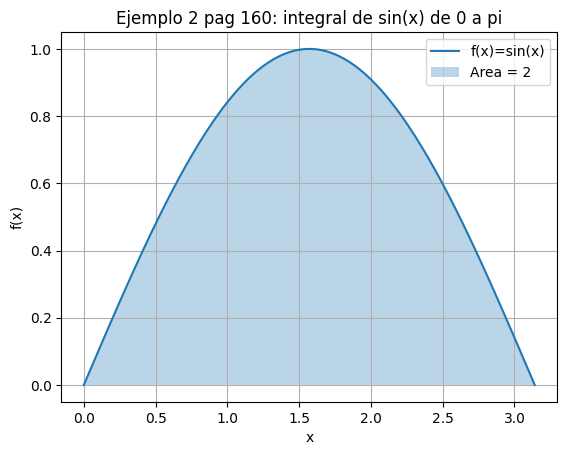

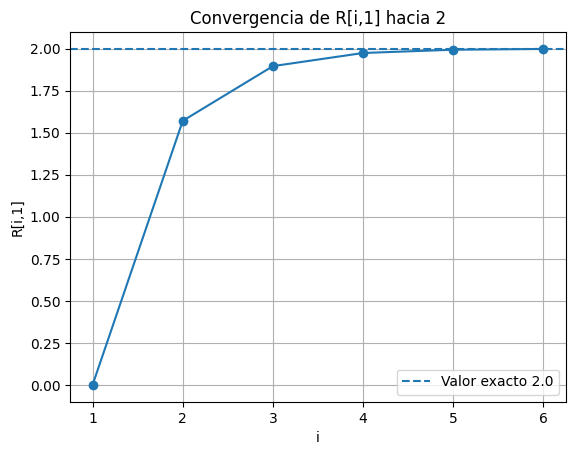

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x)

a = 0.0
b = np.pi

# Grafica 1: area bajo sin(x)
x = np.linspace(a, b, 200)
y = f(x)

plt.figure()
plt.plot(x, y, label='f(x)=sin(x)')
plt.fill_between(x, y, alpha=0.3, label='Area = 2')
plt.title('Ejemplo 2 pag 160: integral de sin(x) de 0 a pi')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()

# Grafica 2: convergencia de R[i,1] a 2
R = np.zeros(7)
h = b-a
R[1] = h/2*(f(a)+f(b))
vals = [R[1]]
for i in range(2,7):
    s = sum(f(a+(k-0.5)*h) for k in range(1, 2**(i-2)+1))
    R[i] = 0.5*(R[i-1] + h*s)
    vals.append(R[i])
    h/=2

plt.figure()
plt.plot(range(1,7), vals, marker='o')
plt.axhline(2.0, linestyle='--', label='Valor exacto 2.0')
plt.title('Convergencia de R[i,1] hacia 2')
plt.xlabel('i')
plt.ylabel('R[i,1]')
plt.grid(True)
plt.legend()
plt.show()